# 19 — Boxplots of Solution Quality Across Runs

**Maps to:** `report/Chapters/Task4.tex` §`T4:Boxplots`.  
**Ticket:** TICKET-19.

Boxplots of final tour length across 30 independent runs, grouped by:

- **Part A:** Constraint-handling strategy (from TICKET-17: repair vs. penalty vs. no-repair)
- **Part B:** Parameter configuration (from TICKET-16: pop_size, mutation_rate, selection_method)

Includes pairwise Wilcoxon signed-rank tests with Bonferroni correction.

Output: `results/figures/boxplot_strategy.pdf`, `results/figures/boxplot_<param>.pdf`.

---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from itertools import combinations

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "figure.figsize": (8, 5),
    "figure.constrained_layout.use": True,
})

FIGURES_DIR = Path("../results/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

OPTIMAL = 21282

---
# Part A — Per-Strategy Boxplots (TICKET-17)

Three constraint-handling strategies compared using naive single-point
crossover on kroA100 (30 runs each).

### Load Data

In [2]:
compare = pd.read_csv(Path("../results/compare.csv"))

print(f"Shape     : {compare.shape}")
print(f"Strategies: {sorted(compare['strategy'].unique())}")
print(f"Runs per strategy:")
print(compare["strategy"].value_counts().to_string())

Shape     : (90, 5)
Strategies: ['no_repair', 'penalty', 'repair']
Runs per strategy:
strategy
repair       30
penalty      30
no_repair    30


### Summary Statistics

In [3]:
summary = compare.groupby("strategy")["best_fitness"].agg(
    ["count", "mean", "std", "min", "median", "max"]
).round(2)
summary["gap_%"] = ((summary["mean"] - OPTIMAL) / OPTIMAL * 100).round(1)

print("Summary Statistics — Best Fitness (lower is better)")
print("=" * 75)
print(summary.to_string())

Summary Statistics — Best Fitness (lower is better)
           count      mean      std       min    median       max  gap_%
strategy                                                                
no_repair     30  38129.27  4135.41  28805.71  37750.48  47741.29   79.2
penalty       30  57947.91  3284.51  48091.74  58079.43  64585.95  172.3
repair        30  49777.84  3186.86  43890.51  49406.18  56629.20  133.9


### Boxplot: Per Constraint-Handling Strategy

Saved: ../results/figures/boxplot_strategy.pdf


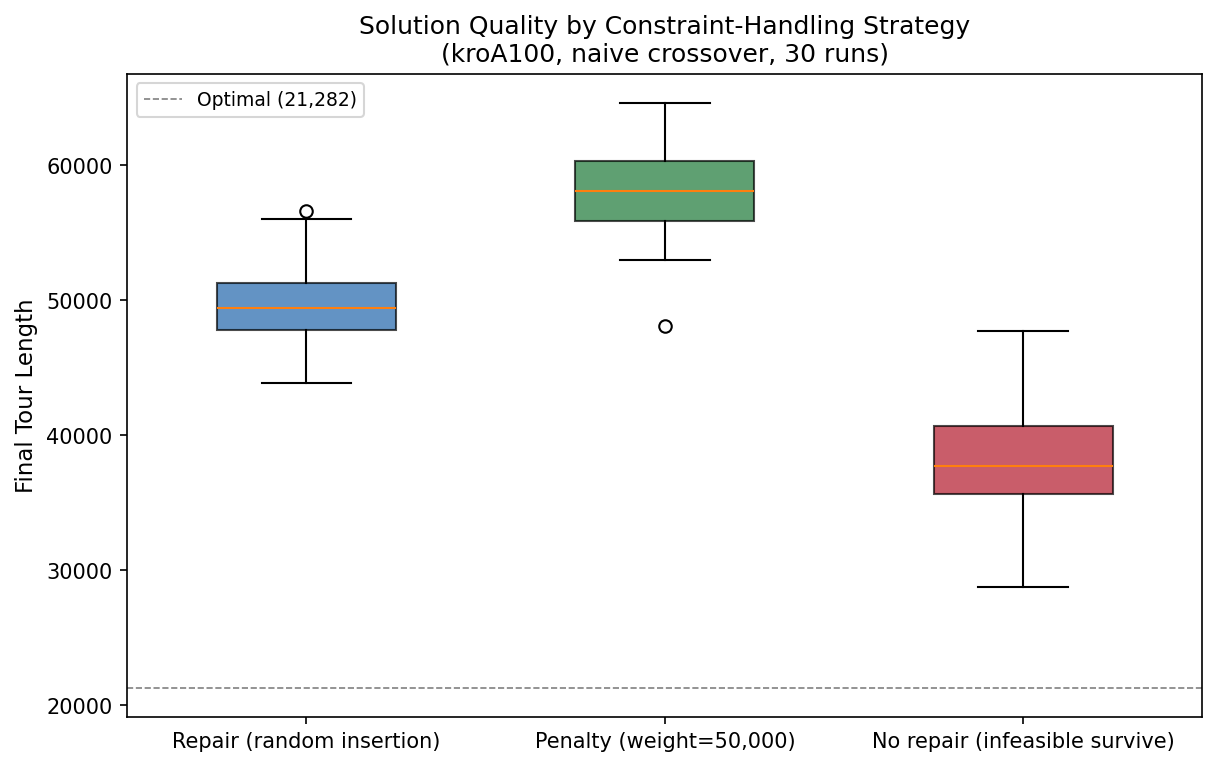

In [4]:
STRATEGY_STYLE = {
    "repair":    {"color": "#2166ac", "label": "Repair (random insertion)"},
    "penalty":   {"color": "#1b7837", "label": "Penalty (weight=50,000)"},
    "no_repair": {"color": "#b2182b", "label": "No repair (infeasible survive)"},
}

strategy_order = ["repair", "penalty", "no_repair"]
data_groups = [compare[compare["strategy"] == s]["best_fitness"].values for s in strategy_order]
labels = [STRATEGY_STYLE[s]["label"] for s in strategy_order]
colors = [STRATEGY_STYLE[s]["color"] for s in strategy_order]

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(data_groups, patch_artist=True, tick_labels=labels, widths=0.5)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8,
           label=f"Optimal ({OPTIMAL:,})")
ax.set_ylabel("Final Tour Length")
ax.set_title("Solution Quality by Constraint-Handling Strategy\n(kroA100, naive crossover, 30 runs)")
ax.legend(loc="upper left")

path = FIGURES_DIR / "boxplot_strategy.pdf"
fig.savefig(path, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

The boxplot shows clear separation between all three strategies.

**No-repair** produces the lowest recorded tour lengths (mean ≈ 38,129, gap 79.2%),
but these are misleading — infeasible chromosomes visit fewer unique cities, yielding
artificially short distances that do not represent valid TSP solutions.

**Repair** (mean ≈ 49,778, gap 133.9%) produces genuinely feasible tours. All 100
cities are visited exactly once, so fitness values are meaningful. The relatively
tight IQR indicates consistent performance across seeds.

**Penalty** (mean ≈ 57,948, gap 172.3%) produces the highest tour lengths. The
penalty weight inflates fitness for infeasible chromosomes, steering selection toward
feasibility — but the GA must "earn" feasibility through selection pressure rather
than enforcing it directly, resulting in slower convergence than repair. The ~16%
gap between penalty and repair is statistically significant (see below).

### Pairwise Wilcoxon Signed-Rank Tests (Bonferroni corrected)

In [5]:
pairs = list(combinations(strategy_order, 2))
alpha = 0.05
alpha_corrected = alpha / len(pairs)

print(f"Pairwise Wilcoxon Signed-Rank Tests (Bonferroni α = {alpha_corrected:.4f})")
print("=" * 70)

for s1, s2 in pairs:
    v1 = compare[compare["strategy"] == s1].sort_values("seed")["best_fitness"].values
    v2 = compare[compare["strategy"] == s2].sort_values("seed")["best_fitness"].values

    stat, p = stats.wilcoxon(v1, v2)
    sig = "Yes" if p < alpha_corrected else "No"
    better = s1 if v1.mean() < v2.mean() else s2

    print(f"\n  {s1} vs {s2}:")
    print(f"    statistic = {stat:.2f}, p = {p:.6f}, reject H₀: {sig}")
    if p < alpha_corrected:
        print(f"    → '{better}' significantly better (lower tour length)")

Pairwise Wilcoxon Signed-Rank Tests (Bonferroni α = 0.0167)

  repair vs penalty:
    statistic = 1.00, p = 0.000000, reject H₀: Yes
    → 'repair' significantly better (lower tour length)

  repair vs no_repair:
    statistic = 0.00, p = 0.000000, reject H₀: Yes
    → 'no_repair' significantly better (lower tour length)

  penalty vs no_repair:
    statistic = 0.00, p = 0.000000, reject H₀: Yes
    → 'no_repair' significantly better (lower tour length)


All three pairwise comparisons are statistically significant at the
Bonferroni-corrected level (α = 0.0167). The ranking by recorded fitness
is no_repair < repair < penalty, but only repair produces valid TSP
solutions — no_repair's apparent advantage is an artefact of infeasibility.

The repair vs. penalty comparison is the most informative: repair
significantly outperforms penalty, confirming that direct feasibility
enforcement via repair is more effective than indirect penalty-based
steering for this problem instance and operator configuration.

---
# Part B — Per-Configuration Boxplots (TICKET-16)

Boxplots from the parameter sensitivity sweep (PMX crossover, repair
enabled). Each box shows the distribution of final tour lengths across
seeds for one parameter value.

### Load Sweep Data

In [6]:
sweep = pd.read_csv(Path("../results/sweep.csv"))

print(f"Shape           : {sweep.shape}")
print(f"pop_size        : {sorted(sweep['pop_size'].unique())}")
print(f"mutation_rate   : {sorted(sweep['mutation_rate'].unique())}")
print(f"selection_method: {sorted(sweep['selection_method'].unique())}")

Shape           : (1620, 9)
pop_size        : [np.int64(50), np.int64(100), np.int64(200)]
mutation_rate   : [np.float64(0.01), np.float64(0.05), np.float64(0.1)]
selection_method: ['roulette', 'tournament']


### Boxplot: By Population Size

Saved: ../results/figures/boxplot_pop_size.pdf


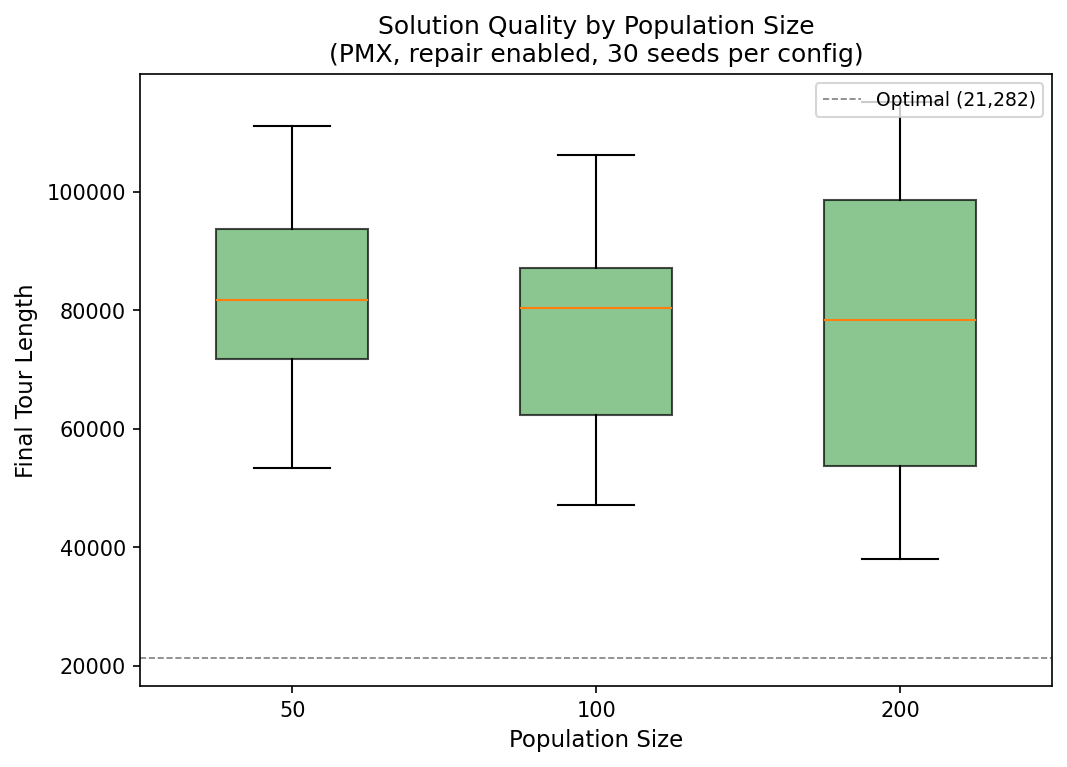

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
pop_sizes = sorted(sweep["pop_size"].unique())
data_groups = [sweep[sweep["pop_size"] == v]["best_fitness"].values for v in pop_sizes]

bp = ax.boxplot(data_groups, patch_artist=True,
                tick_labels=[str(v) for v in pop_sizes], widths=0.5)
for patch in bp["boxes"]:
    patch.set_facecolor("#5aae61")
    patch.set_alpha(0.7)

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8,
           label=f"Optimal ({OPTIMAL:,})")
ax.set_xlabel("Population Size")
ax.set_ylabel("Final Tour Length")
ax.set_title("Solution Quality by Population Size\n(PMX, repair enabled, 30 seeds per config)")
ax.legend(loc="upper right")

path = FIGURES_DIR / "boxplot_pop_size.pdf"
fig.savefig(path, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

### Boxplot: By Mutation Rate

Saved: ../results/figures/boxplot_mutation_rate.pdf


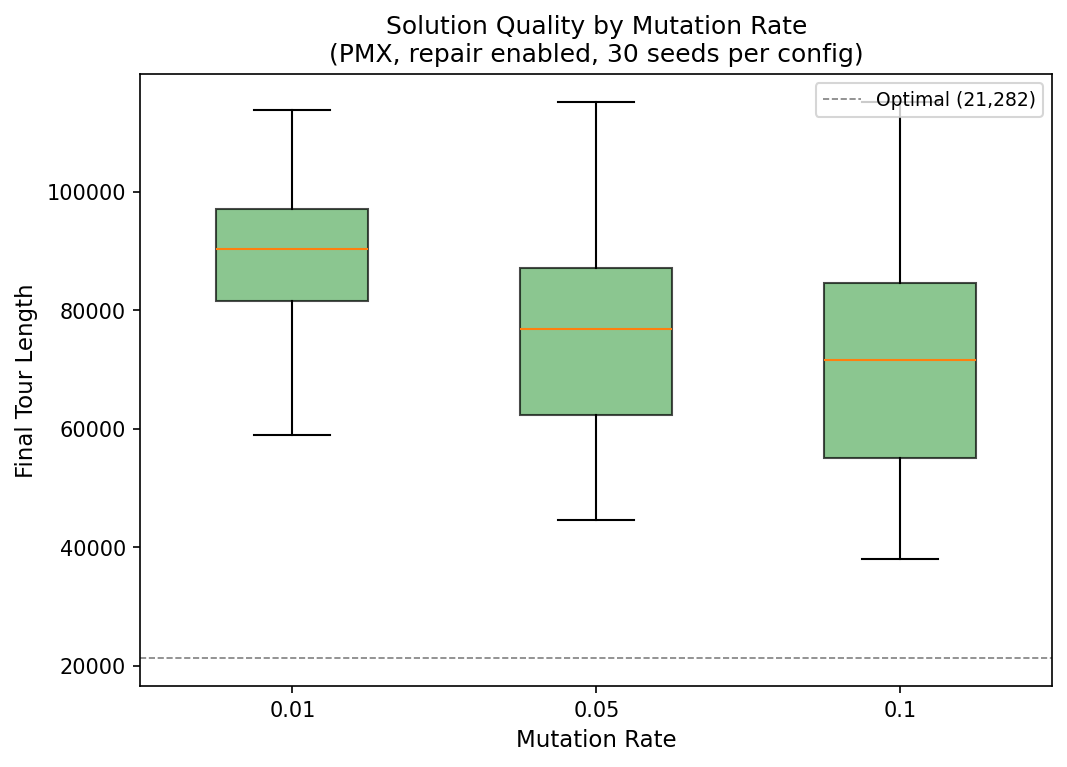

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
mutation_rates = sorted(sweep["mutation_rate"].unique())
data_groups = [sweep[sweep["mutation_rate"] == v]["best_fitness"].values for v in mutation_rates]

bp = ax.boxplot(data_groups, patch_artist=True,
                tick_labels=[str(v) for v in mutation_rates], widths=0.5)
for patch in bp["boxes"]:
    patch.set_facecolor("#5aae61")
    patch.set_alpha(0.7)

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8,
           label=f"Optimal ({OPTIMAL:,})")
ax.set_xlabel("Mutation Rate")
ax.set_ylabel("Final Tour Length")
ax.set_title("Solution Quality by Mutation Rate\n(PMX, repair enabled, 30 seeds per config)")
ax.legend(loc="upper right")

path = FIGURES_DIR / "boxplot_mutation_rate.pdf"
fig.savefig(path, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

### Boxplot: By Selection Method

Saved: ../results/figures/boxplot_selection_method.pdf


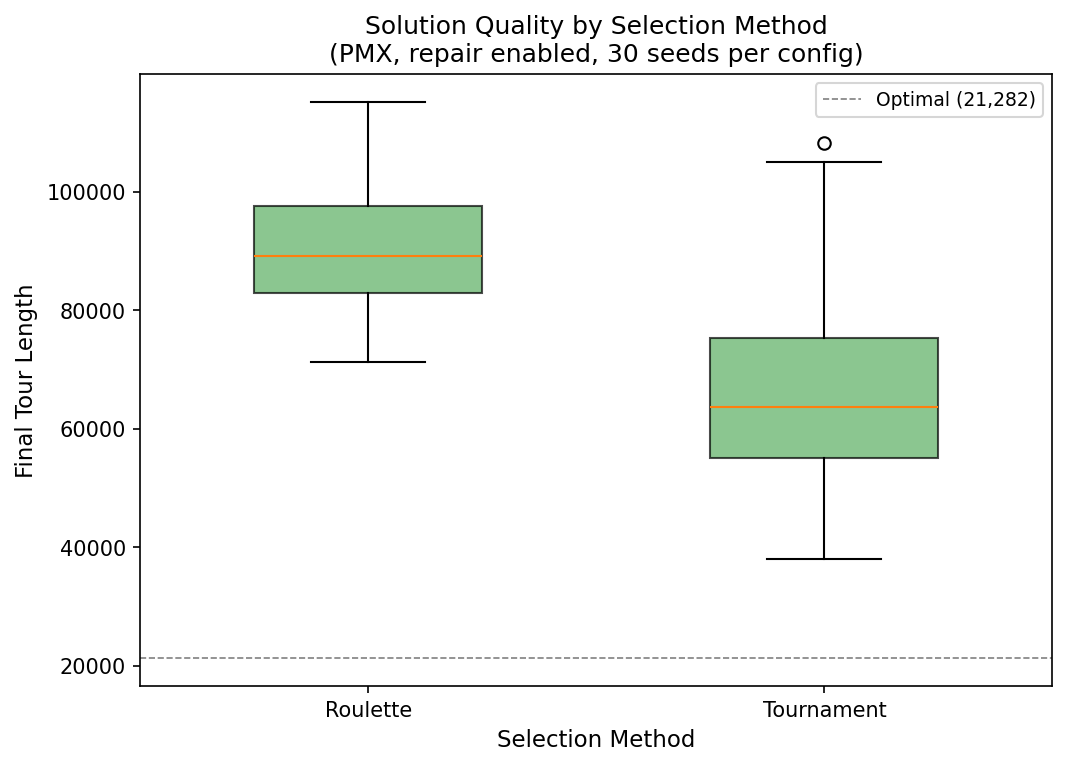

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
methods = sorted(sweep["selection_method"].unique())
data_groups = [sweep[sweep["selection_method"] == m]["best_fitness"].values for m in methods]

bp = ax.boxplot(data_groups, patch_artist=True,
                tick_labels=[m.capitalize() for m in methods], widths=0.5)
for patch in bp["boxes"]:
    patch.set_facecolor("#5aae61")
    patch.set_alpha(0.7)

ax.axhline(y=OPTIMAL, color="gray", linestyle="--", linewidth=0.8,
           label=f"Optimal ({OPTIMAL:,})")
ax.set_xlabel("Selection Method")
ax.set_ylabel("Final Tour Length")
ax.set_title("Solution Quality by Selection Method\n(PMX, repair enabled, 30 seeds per config)")
ax.legend(loc="upper right")

path = FIGURES_DIR / "boxplot_selection_method.pdf"
fig.savefig(path, bbox_inches="tight")
print(f"Saved: {path}")
plt.show()

### Per-Configuration Interpretation

In [10]:
print("Median best fitness by parameter value")
print("=" * 50)
for param in ["pop_size", "mutation_rate", "selection_method"]:
    medians = sweep.groupby(param)["best_fitness"].median().sort_values()
    print(f"\n{param}:")
    for val, med in medians.items():
        print(f"  {val:>12}  →  median = {med:,.0f}")
    best_val = medians.index[0]
    print(f"  Best: {best_val}")

Median best fitness by parameter value

pop_size:
           200  →  median = 78,366
           100  →  median = 80,377
            50  →  median = 81,744
  Best: 200

mutation_rate:
           0.1  →  median = 71,606
          0.05  →  median = 76,747
          0.01  →  median = 90,322
  Best: 0.1

selection_method:
    tournament  →  median = 63,674
      roulette  →  median = 89,059
  Best: tournament


The per-configuration boxplots reveal:

- **Population size:** Larger populations produce lower median tour lengths
  (200 → 78,366; 100 → 80,377; 50 → 81,744). The effect is consistent but
  relatively modest — the gap between 50 and 200 is small compared to the
  within-group variance.
- **Mutation rate:** Higher mutation rates strongly outperform the lowest rate
  (0.1 → 71,606; 0.05 → 76,747; 0.01 → 90,322). The low rate likely causes
  premature convergence. This is the second-largest effect among the three
  parameters.
- **Selection method:** Tournament selection (median 63,674) substantially
  outperforms roulette (median 89,059) — the largest single-parameter effect
  in the sweep. Tournament's stronger selection pressure appears to drive
  faster convergence toward better solutions on this problem instance.

---
## Summary

**Part A** — Boxplot + Wilcoxon tests for 3 constraint-handling strategies
(repair, penalty, no-repair). All pairwise differences are statistically
significant. Repair produces valid tours with the best meaningful fitness;
no-repair's lower values are artefacts of infeasibility.

**Part B** — Per-parameter boxplots from the TICKET-16 sweep. Selection
method has the largest effect (tournament >> roulette), followed by
mutation rate (0.1 > 0.05 >> 0.01). Population size has a consistent
but comparatively small effect.

Figures saved to `results/figures/`:
- `boxplot_strategy.pdf`
- `boxplot_pop_size.pdf`
- `boxplot_mutation_rate.pdf`
- `boxplot_selection_method.pdf`